In [2]:
library(ggplot2)
head(iris)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


In [3]:
df <- read.csv("data/borrow_records_clean.csv", fileEncoding = "UTF-8-BOM")

In [4]:
nrow(df)

[1] 148

In [5]:
str(df)

'data.frame':	148 obs. of  5 variables:
 $ 读者编号: chr  "R1000" "R1001" "R1002" "R1003" ...
 $ 学院    : chr  "信息管理" "计算机" "法学" "信息管理" ...
 $ 月份    : int  1 1 1 1 3 1 1 1 2 2 ...
 $ 借阅量  : num  190 36 152 24 155 184 115 195 72 27 ...
 $ 逾期数  : num  17 6 27 13 1 34 37 10 9 5 ...


In [6]:
agg <- aggregate(借阅量 ~ 学院, data = df, FUN = sum)
agg

学院,借阅量
<chr>,<dbl>
法学,3451
计算机,2625
历史,2461
文学,13191
信息管理,3958


In [7]:
agg <- agg[order(agg$借阅量, decreasing = TRUE), ]
agg

,学院,借阅量
,<chr>,<dbl>
4,文学,13191
5,信息管理,3958
1,法学,3451
2,计算机,2625
3,历史,2461


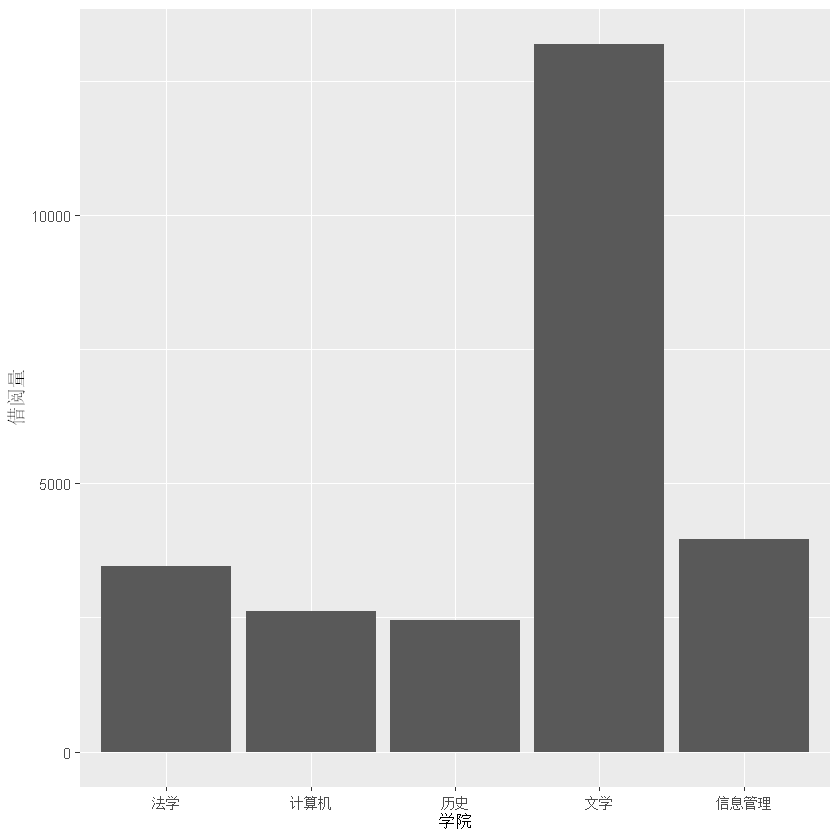

In [8]:
library(ggplot2)
ggplot(agg, aes(x = 学院, y = 借阅量)) + geom_col()

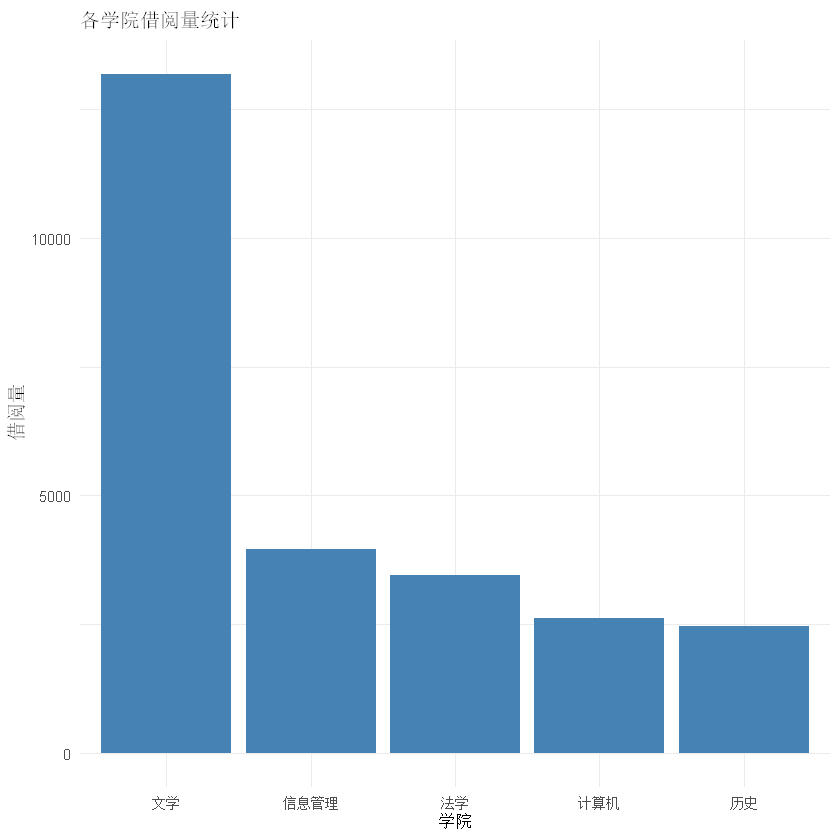

In [9]:
ggplot(agg, aes(x = reorder(学院, -借阅量), y = 借阅量)) +
  geom_col(fill = "steelblue") +
  theme_minimal() +
  labs(title = "各学院借阅量统计", x = "学院", y = "借阅量")
ggsave("outputs/学院借阅量.png", width = 8, height = 5)

In [10]:
max(df$借阅量)
df[df$借阅量 > 5000, ]

[1] 9999

,读者编号,学院,月份,借阅量,逾期数
,<chr>,<chr>,<int>,<dbl>,<dbl>
29,R1030,文学,3,9999,23


这个数据很有问题，异常大，而且数字很特殊，应该引起我的敏感，以后应该记得排查这种数据，极有可能为假。